In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import neurite as ne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


2025-11-19 18:49:51.052900: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-19 18:49:51.052949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-19 18:49:51.054474: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
subj1 = np.load('../Data/subj1.npz')
subj2 = np.load('../Data/subj2.npz')

volumes = np.stack([subj1['vol'], subj2['vol']]).astype('float32')
vol_shape = volumes.shape[1:]
print('Loaded volumes:', volumes.shape, 'vol_shape:', vol_shape)

x_tensor = torch.from_numpy(volumes).unsqueeze(1)

pair_indices = torch.tensor(
    [(i, j) for i in range(x_tensor.shape[0]) for j in range(x_tensor.shape[0]) if i != j],
    dtype=torch.long
)
print('Total ordered volume pairs:', pair_indices.shape[0])


Loaded volumes: (2, 160, 192, 224) vol_shape: (160, 192, 224)
Total ordered volume pairs: 2


In [3]:
ORIENTATIONS = ('axial', 'coronal', 'sagittal')
MAX_SLICES_PER_ORIENTATION = 88
SLICE_CHUNK = 16

train_slice_orientations = ORIENTATIONS

def sample_volume_pair(x_data, pair_indices, device=device):
    idx = torch.randint(0, pair_indices.shape[0], (1,)).item()
    moving = x_data[pair_indices[idx, 0]].unsqueeze(0).to(device)
    fixed = x_data[pair_indices[idx, 1]].unsqueeze(0).to(device)
    return moving, fixed


def volume_to_slices(volume, orientation):
    vol = volume[0, 0]
    if orientation == 'axial':
        data = vol
    elif orientation == 'coronal':
        data = vol.permute(1, 0, 2)
    elif orientation == 'sagittal':
        data = vol.permute(2, 0, 1)
    else:
        raise ValueError(f'Unknown orientation: {orientation}')
    return data.unsqueeze(1)


def lift_flow(flow_slices, orientation, indices):
    flow_vol = torch.zeros((1, 3, *vol_shape), device=device)
    counts = torch.zeros_like(flow_vol)
    for flow_slice, idx in zip(flow_slices, indices):
        if orientation == 'axial':
            flow_vol[:, 0, idx, :, :] = flow_slice[0]
            flow_vol[:, 1, idx, :, :] = flow_slice[1]
            counts[:, 0, idx, :, :] += 1.0
            counts[:, 1, idx, :, :] += 1.0
        elif orientation == 'coronal':
            flow_vol[:, 0, :, idx, :] = flow_slice[0]
            flow_vol[:, 2, :, idx, :] = flow_slice[1]
            counts[:, 0, :, idx, :] += 1.0
            counts[:, 2, :, idx, :] += 1.0
        else:
            flow_vol[:, 1, :, :, idx] = flow_slice[0]
            flow_vol[:, 2, :, :, idx] = flow_slice[1]
            counts[:, 1, :, :, idx] += 1.0
            counts[:, 2, :, :, idx] += 1.0
    return flow_vol, counts


def accumulate_orientation_flow(moving, fixed, orientation, max_slices=MAX_SLICES_PER_ORIENTATION):
    moving_slices = volume_to_slices(moving, orientation)
    fixed_slices = volume_to_slices(fixed, orientation)
    total = moving_slices.shape[0]

    if max_slices is None or max_slices >= total:
        slice_indices = torch.arange(total)
    else:
        slice_indices = torch.randperm(total)[:max_slices]
        slice_indices = slice_indices.sort().values

    flows = []
    idxs = []
    aux_loss = 0.0
    for idx in slice_indices.tolist():
        moving_slice = moving_slices[idx:idx+1].to(device)
        fixed_slice = fixed_slices[idx:idx+1].to(device)
        moved_slice, flow_slice = slice_model(moving_slice, fixed_slice)
        flows.append(flow_slice[0])
        idxs.append(idx)
        aux_loss = aux_loss + F.mse_loss(moved_slice, fixed_slice)

    flow_vol, counts = lift_flow(flows, orientation, idxs)
    if len(slice_indices) > 0:
        aux_loss = aux_loss / len(slice_indices)
    return flow_vol, counts, aux_loss


def fuse_oriented_flows(flows, counts):
    aggregated = torch.stack(flows).sum(dim=0)
    total_counts = torch.stack(counts).sum(dim=0)
    return aggregated / total_counts.clamp(min=1.0)


In [4]:
class SpatialTransformer2D(nn.Module):
    def forward(self, src, flow):
        b, _, h, w = src.shape
        device = src.device
        yy, xx = torch.meshgrid(
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        grid = torch.stack((xx, yy), dim=0).float()
        grid = grid.unsqueeze(0).repeat(b, 1, 1, 1)
        pts = grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0
        sample_grid = torch.stack((x, y), dim=-1)
        return F.grid_sample(src, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)

class ConvBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))

class SliceRegistrationNet(nn.Module):
    def __init__(self, enc_feats=(12, 24, 24), final_feats=(32, 24)):
        super().__init__()
        self.encoders = nn.ModuleList()
        in_channels = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock2D(in_channels, nf))
            in_channels = nf
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock2D(enc_feats[-1], enc_feats[-1])
        self.decoders = nn.ModuleList()
        decoder_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock2D(decoder_in + skip_ch, skip_ch))
            decoder_in = skip_ch
        self.final_conv0 = ConvBlock2D(decoder_in, final_feats[0])
        self.final_conv1 = ConvBlock2D(final_feats[0], final_feats[1])
        self.flow = nn.Conv2d(final_feats[1], 2, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer2D()
        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity='leaky_relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, src, tgt):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='nearest')
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        moved = self.transformer(src, flow)
        return moved, flow

class SpatialTransformer3D(nn.Module):
    def forward(self, src, flow):
        b, _, d, h, w = src.shape
        device = src.device
        zz, yy, xx = torch.meshgrid(
            torch.arange(d, device=device),
            torch.arange(h, device=device),
            torch.arange(w, device=device),
            indexing='ij'
        )
        grid = torch.stack((xx, yy, zz), dim=0).float()
        grid = grid.unsqueeze(0).repeat(b, 1, 1, 1, 1)
        pts = grid + flow
        x = 2.0 * (pts[:, 0] / (w - 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / (h - 1.0)) - 1.0
        z = 2.0 * (pts[:, 2] / (d - 1.0)) - 1.0
        sample_grid = torch.stack((x, y, z), dim=-1)
        return F.grid_sample(src, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)

def flow_grad_l2_3d(flow):
    dx = flow[:, :, :, :, 1:] - flow[:, :, :, :, :-1]
    dy = flow[:, :, :, 1:, :] - flow[:, :, :, :-1, :]
    dz = flow[:, :, 1:, :, :] - flow[:, :, :-1, :, :]
    dx = F.pad(dx, (0, 1, 0, 0, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1, 0, 0))
    dz = F.pad(dz, (0, 0, 0, 0, 0, 1))
    return dx.pow(2).mean() + dy.pow(2).mean() + dz.pow(2).mean()


In [5]:
slice_model = SliceRegistrationNet().to(device)
transformer3d = SpatialTransformer3D().to(device)
optimizer = torch.optim.AdamW(slice_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)


In [6]:
slice_model.eval()

with torch.no_grad():

    moving, fixed = sample_volume_pair(x_tensor, pair_indices, device=device)

    flows = []

    counts = []

    for orientation in ORIENTATIONS:

        flow_vol, count_vol, _ = accumulate_orientation_flow(moving, fixed, orientation)

        flows.append(flow_vol)

        counts.append(count_vol)

    fused_flow = fuse_oriented_flows(flows, counts)

    moved = transformer3d(moving, fused_flow)

print('Sanity check shapes -> moved:', moved.shape, 'flow:', fused_flow.shape)



Sanity check shapes -> moved: torch.Size([1, 1, 160, 192, 224]) flow: torch.Size([1, 3, 160, 192, 224])


In [7]:
torch.cuda.empty_cache()

epochs = 200
steps_per_epoch = 8
patience = 10
smooth_weight = 0.01
aux_weight = 0.2

history = []
best_loss = float('inf')
no_improve = 0

for epoch in range(epochs):
    slice_model.train()
    running_loss = 0.0
    for _ in range(steps_per_epoch):
        moving, fixed = sample_volume_pair(x_tensor, pair_indices, device=device)

        flows = []
        counts = []
        aux_losses = 0.0
        for orientation in ORIENTATIONS:
            flow_vol, count_vol, aux_loss = accumulate_orientation_flow(moving, fixed, orientation, max_slices=MAX_SLICES_PER_ORIENTATION)
            flows.append(flow_vol)
            counts.append(count_vol)
            aux_losses = aux_losses + aux_loss

        fused_flow = fuse_oriented_flows(flows, counts)
        moved = transformer3d(moving, fused_flow)

        recon = F.mse_loss(moved, fixed)
        smooth = flow_grad_l2_3d(fused_flow)
        loss = recon + smooth_weight * smooth + aux_weight * aux_losses

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    epoch_loss = running_loss / steps_per_epoch
    history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} -- loss: {epoch_loss:.6f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

history = np.array(history)


Epoch 1/200 -- loss: 0.004352
Epoch 2/200 -- loss: 0.004316
Epoch 3/200 -- loss: 0.004304
Epoch 4/200 -- loss: 0.004321
Epoch 5/200 -- loss: 0.004280
Epoch 6/200 -- loss: 0.004316
Epoch 7/200 -- loss: 0.004310
Epoch 8/200 -- loss: 0.004279
Epoch 9/200 -- loss: 0.004264
Epoch 10/200 -- loss: 0.004237
Epoch 11/200 -- loss: 0.004219
Epoch 12/200 -- loss: 0.004170
Epoch 13/200 -- loss: 0.004142
Epoch 14/200 -- loss: 0.004054
Epoch 15/200 -- loss: 0.004015
Epoch 16/200 -- loss: 0.003976
Epoch 17/200 -- loss: 0.003943
Epoch 18/200 -- loss: 0.003918
Epoch 19/200 -- loss: 0.003851
Epoch 20/200 -- loss: 0.003812
Epoch 21/200 -- loss: 0.003769
Epoch 22/200 -- loss: 0.003703
Epoch 23/200 -- loss: 0.003669
Epoch 24/200 -- loss: 0.003614
Epoch 25/200 -- loss: 0.003578
Epoch 26/200 -- loss: 0.003567
Epoch 27/200 -- loss: 0.003526
Epoch 28/200 -- loss: 0.003515
Epoch 29/200 -- loss: 0.003511
Epoch 30/200 -- loss: 0.003488
Epoch 31/200 -- loss: 0.003447
Epoch 32/200 -- loss: 0.003441
Epoch 33/200 -- l

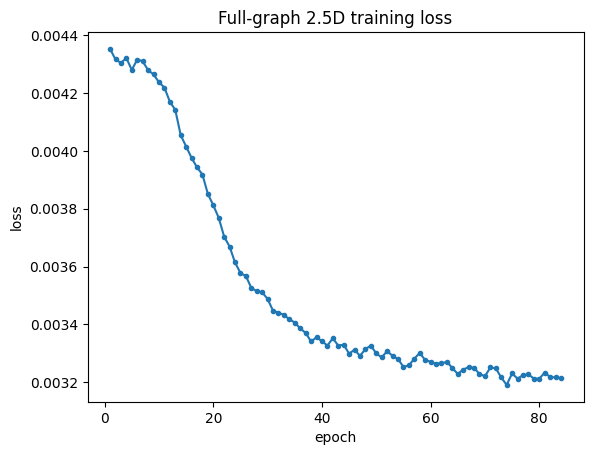

In [8]:
plt.figure()
plt.plot(np.arange(1, len(history) + 1), history, '.-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Full-graph 2.5D training loss')
plt.show()


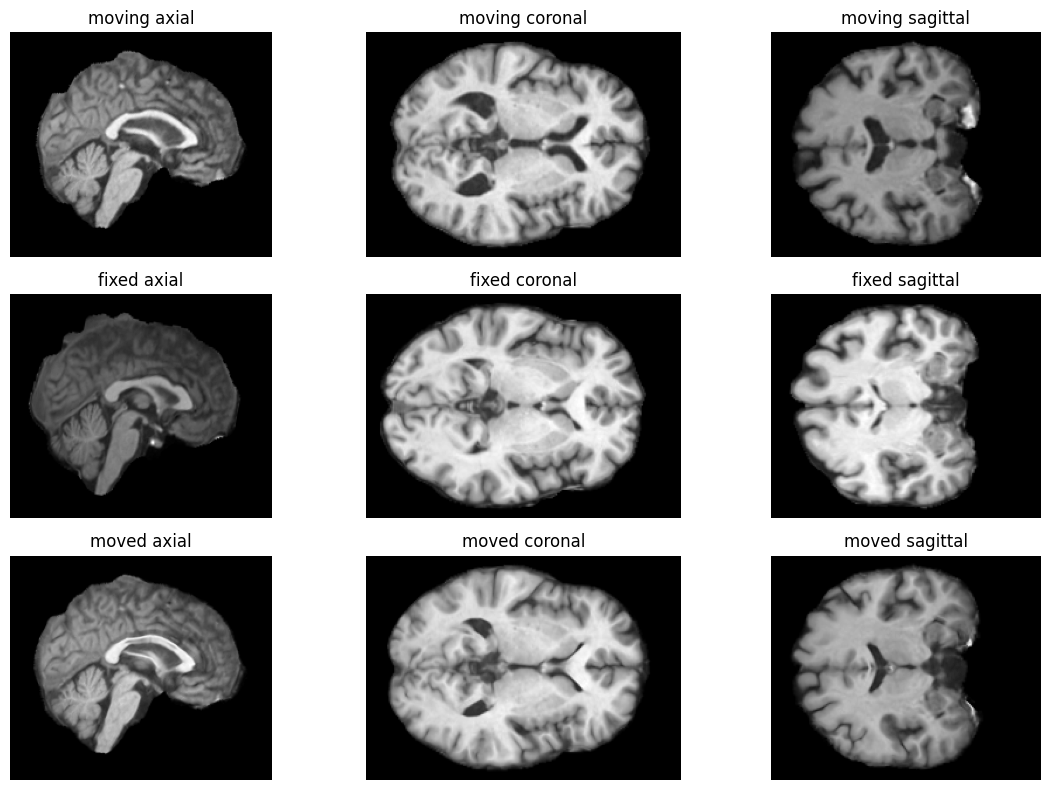

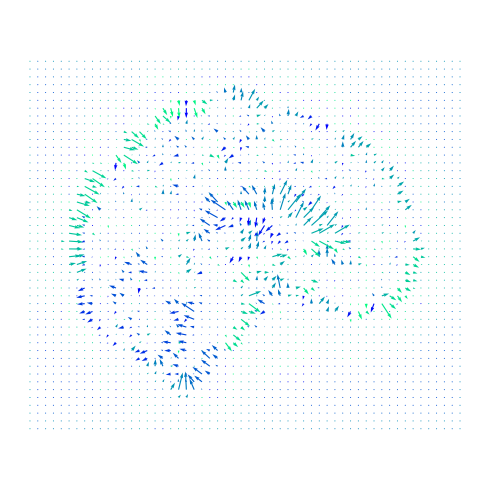

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [9]:
slice_model.eval()



with torch.no_grad():



    moving, fixed = sample_volume_pair(x_tensor, pair_indices, device=device)



    flows = []



    counts = []



    for orientation in ORIENTATIONS:



        flow_vol, count_vol, _ = accumulate_orientation_flow(moving, fixed, orientation, max_slices=None)



        flows.append(flow_vol)



        counts.append(count_vol)



    fused_flow = fuse_oriented_flows(flows, counts)



    moved = transformer3d(moving, fused_flow)







moving_np = moving[0, 0].cpu().numpy()



fixed_np = fixed[0, 0].cpu().numpy()



moved_np = moved[0, 0].cpu().numpy()



flow_np = fused_flow[0].permute(1, 2, 3, 0).cpu().numpy()







def mid_slices(volume):



    axial = volume[volume.shape[0] // 2]



    coronal = volume[:, volume.shape[1] // 2, :]



    sagittal = volume[:, :, volume.shape[2] // 2]



    return [axial, coronal, sagittal]







vols = mid_slices(moving_np) + mid_slices(fixed_np) + mid_slices(moved_np)



titles = ['moving axial', 'moving coronal', 'moving sagittal',



          'fixed axial', 'fixed coronal', 'fixed sagittal',



          'moved axial', 'moved coronal', 'moved sagittal']



plt.figure(figsize=(12, 8))



for idx, (img, title) in enumerate(zip(vols, titles), 1):



    plt.subplot(3, 3, idx)



    plt.imshow(img, cmap='gray')



    plt.title(title)



    plt.axis('off')



plt.tight_layout()



plt.show()







mid_z = flow_np.shape[0] // 2



axial_flow = flow_np[mid_z, :, :, :2]



step = 4



ne.plot.flow([axial_flow[::step, ::step, :]], width=5)





In [10]:
import os
save_dir = '../trained_weights'
os.makedirs(save_dir, exist_ok=True)
full_slice_path = os.path.join(save_dir, '2p5_full_slice.pth')
torch.save(slice_model.state_dict(), full_slice_path)
print('Saved full-graph slice model to', full_slice_path)


Saved full-graph slice model to ../trained_weights/2p5_full_slice.pth
